# 1.Adequação do nível (IAN)
Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao
longo do ano?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
df = pd.read_csv("base_historico.csv")

In [ ]:
print("Colunas disponíveis:")
print(df.columns)

Colunas disponíveis:
Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra', 'INDE',
       'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Ano', 'Data de Nasc', 'IPP', 'Escola',
       'Ativo/ Inativo'],
      dtype='object')


In [ ]:
col_ian = "IAN"
col_fase = "Fase"

In [ ]:
df = df[[col_ian, col_fase]].dropna()

In [ ]:
print("\n Estatísticas do IAN:")
desc = df[col_ian].describe()
print(desc)


 Estatísticas do IAN:
count    3030.000000
mean        7.179043
std         2.535266
min         2.500000
25%         5.000000
50%         5.000000
75%        10.000000
max        10.000000
Name: IAN, dtype: float64


In [ ]:
media = df[col_ian].mean()
mediana = df[col_ian].median()
desvio = df[col_ian].std()
minimo = df[col_ian].min()
maximo = df[col_ian].max()

print("\nResumo:")
print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desvio padrão: {desvio:.2f}")
print(f"Mínimo: {minimo}")
print(f"Máximo: {maximo}")


Resumo:
Média: 7.18
Mediana: 5.00
Desvio padrão: 2.54
Mínimo: 2.5
Máximo: 10.0


In [ ]:
ian_por_fase = df.groupby(col_fase)[col_ian].mean().sort_index()

print("\n IAN médio por fase:")
print(ian_por_fase)


 IAN médio por fase:
Fase
0          6.802632
1          5.742188
1A         6.071429
1B         7.000000
1C         6.785714
            ...    
FASE 4     7.473404
FASE 5     6.730769
FASE 6     6.363636
FASE 7     8.695652
FASE 8    10.000000
Name: IAN, Length: 88, dtype: float64


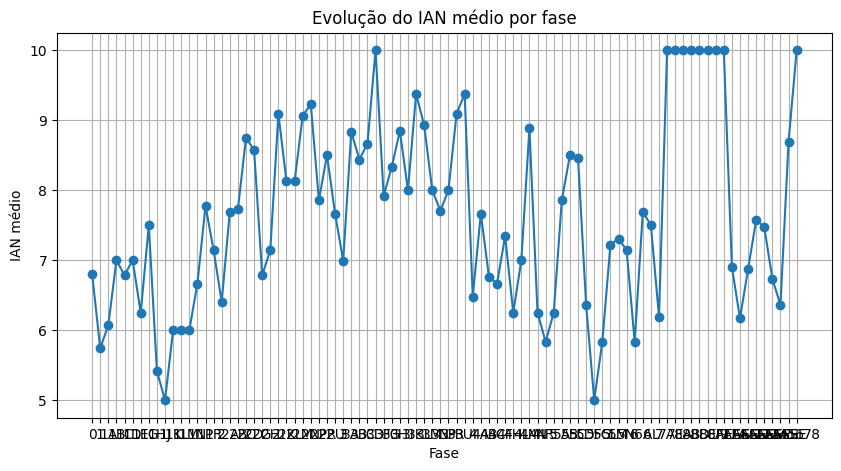

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(ian_por_fase.index, ian_por_fase.values, marker='o')

plt.title("Evolução do IAN médio por fase")
plt.xlabel("Fase")
plt.ylabel("IAN médio")
plt.grid()

plt.show()

In [ ]:
print("\n Interpretação automática:")

if ian_por_fase.is_monotonic_increasing:
    print("O IAN apresenta melhora contínua ao longo das fases.")
elif ian_por_fase.is_monotonic_decreasing:
    print("O IAN apresenta piora contínua ao longo das fases.")
else:
    print("O IAN apresenta comportamento oscilatório ao longo das fases.")

if desvio > 2:
    print("Alta dispersão: há desigualdade relevante entre os alunos.")
else:
    print("Baixa dispersão: os alunos têm níveis semelhantes.")


 Interpretação automática:
O IAN apresenta comportamento oscilatório ao longo das fases.
Alta dispersão: há desigualdade relevante entre os alunos.


# 2.Desempenho acadêmico (IDA)
O desempenho acadêmico médio (IDA) está melhorando, estagnado ou
caindo ao longo das fases e anos?

In [ ]:
df = pd.read_csv("base_historico.csv")
print(df.columns)

Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra', 'INDE',
       'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Ano', 'Data de Nasc', 'IPP', 'Escola',
       'Ativo/ Inativo'],
      dtype='object')


In [ ]:
col_ida = "IDA"
col_fase = "Fase"
col_ano = "Ano ingresso"

In [ ]:
df = df[[col_ida, col_fase, col_ano]].dropna()

In [ ]:
ida_por_fase = df.groupby(col_fase)[col_ida].mean().sort_index()

print("\n IDA médio por fase:")
print(ida_por_fase)


 IDA médio por fase:
Fase
0         7.140000
1         6.464062
1A        7.571429
1B        7.183333
1C        7.285714
            ...   
FASE 3    5.746970
FASE 4    6.004255
FASE 5    5.904615
FASE 6    6.809091
FASE 7    7.810000
Name: IDA, Length: 82, dtype: float64


In [ ]:
ida_por_ano = df.groupby(col_ano)[col_ida].mean().sort_index()

print("\n IDA médio por ano:")
print(ida_por_ano)


 IDA médio por ano:
Ano ingresso
2016    5.950000
2017    6.082353
2018    5.835714
2019    6.028205
2020    6.589655
2021    6.412389
2022    6.293774
2023    6.685969
2024    6.455587
Name: IDA, dtype: float64


In [ ]:
ida_fase_ano = df.groupby([col_ano, col_fase])[col_ida].mean().unstack()

print("\n IDA por fase e ano:")
print(ida_fase_ano)


 IDA por fase e ano:
Fase                 0         1        1A        1B       1C      1D     1E  \
Ano ingresso                                                                   
2016               NaN  5.100000       NaN       NaN      NaN     NaN    NaN   
2017               NaN  5.850000       NaN       NaN      NaN     NaN    NaN   
2018               NaN  6.437500       NaN       NaN      NaN     NaN    NaN   
2019          7.266667  6.338710       NaN       NaN      NaN     NaN    NaN   
2020          7.600000  6.988000       NaN       NaN      NaN     NaN    NaN   
2021          7.356410  6.902500       NaN  3.750000      NaN     NaN    NaN   
2022          7.061702  6.182353  6.500000  6.000000   5.9000  1.0000  6.250   
2023               NaN       NaN  8.055556  7.675000   7.8125  5.5000  4.875   
2024               NaN       NaN  6.750000  7.083333  10.0000  7.4375  6.900   

Fase              1G        1H        1J  ...        7E   8F      ALFA  \
Ano ingresso           

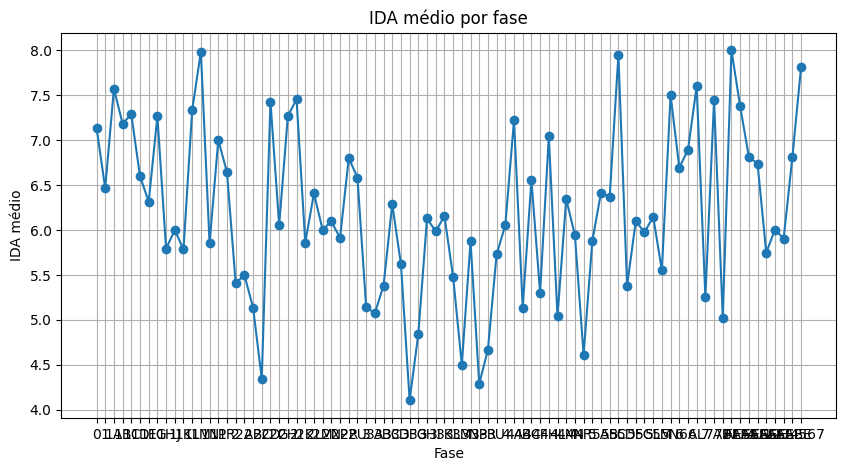

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(ida_por_fase.index, ida_por_fase.values, marker='o')
plt.title("IDA médio por fase")
plt.xlabel("Fase")
plt.ylabel("IDA médio")
plt.grid()
plt.show()

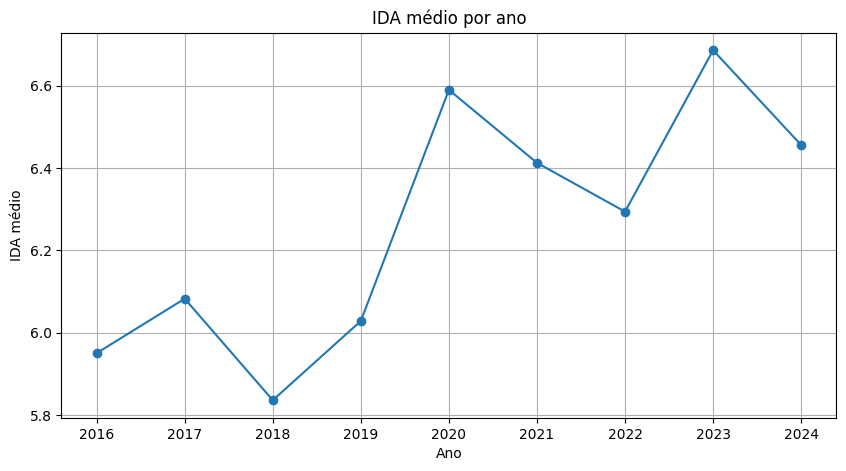

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(ida_por_ano.index, ida_por_ano.values, marker='o')
plt.title("IDA médio por ano")
plt.xlabel("Ano")
plt.ylabel("IDA médio")
plt.grid()
plt.show()

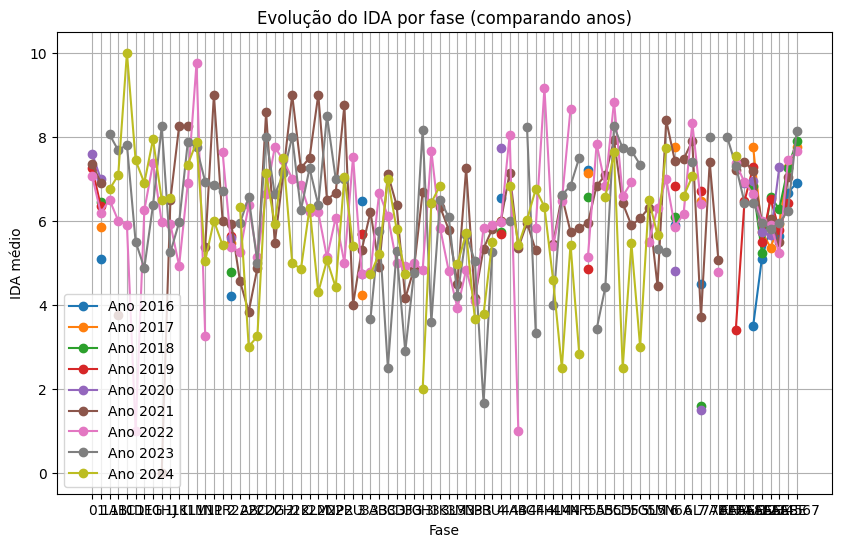

In [ ]:
plt.figure(figsize=(10,6))
for ano in ida_fase_ano.index:
    plt.plot(ida_fase_ano.columns, ida_fase_ano.loc[ano], marker='o', label=f"Ano {ano}")

plt.title("Evolução do IDA por fase (comparando anos)")
plt.xlabel("Fase")
plt.ylabel("IDA médio")
plt.legend()
plt.grid()
plt.show()

In [ ]:
x_fase = np.arange(len(ida_por_fase.index))
y_fase = ida_por_fase.values

coef_fase = np.polyfit(x_fase, y_fase, 1)[0]

In [ ]:
x_ano = ida_por_ano.index.values
y_ano = ida_por_ano.values

coef_ano = np.polyfit(x_ano, y_ano, 1)[0]

print("\n Interpretação automática:")

if coef_fase > 0:
    print("O IDA melhora ao longo das fases.")
elif coef_fase < 0:
    print("O IDA piora ao longo das fases.")
else:
    print(" O IDA está estagnado nas fases.")

if coef_ano > 0:
    print("O desempenho melhora ao longo dos anos.")
elif coef_ano < 0:
    print("O desempenho está caindo ao longo dos anos.")
else:
  print("O desempenho está estagnado ao longo dos anos.")


 Interpretação automática:
O IDA piora ao longo das fases.
O desempenho melhora ao longo dos anos.


In [ ]:
x_ano = ida_por_ano.index.values
y_ano = ida_por_ano.values

coef_ano = np.polyfit(x_ano, y_ano, 1)[0]

print("\n Interpretação automática:")

if coef_fase > 0:
    print("O IDA melhora ao longo das fases.")
elif coef_fase < 0:
    print("O IDA piora ao longo das fases.")
else:
    print(" O IDA está estagnado nas fases.")

if coef_ano > 0:
    print("O desempenho melhora ao longo dos anos.")
elif coef_ano < 0:
    print("O desempenho está caindo ao longo dos anos.")
else:
  print("O desempenho está estagnado ao longo dos anos.")


 Interpretação automática:
O IDA piora ao longo das fases.
O desempenho melhora ao longo dos anos.


#3. Engajamento nas atividades (IEG)
O grau de engajamento dos alunos (IEG) tem relação direta com seus
indicadores de desempenho (IDA) e do ponto de virada (IPV)?

In [ ]:
df = pd.read_csv("base_historico.csv")

print(df.columns)

Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra', 'INDE',
       'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Ano', 'Data de Nasc', 'IPP', 'Escola',
       'Ativo/ Inativo'],
      dtype='object')


In [ ]:
col_ieg = "IEG"
col_ida = "IDA"
col_ipv = "IPV"

In [ ]:
df = df[[col_ieg, col_ida, col_ipv]].dropna()

In [ ]:
corr = df.corr()

print("\n Matriz de correlação:")
print(corr)

corr_ieg_ida = corr.loc[col_ieg, col_ida]
corr_ieg_ipv = corr.loc[col_ieg, col_ipv]

print("\nCorrelação IEG x IDA:", round(corr_ieg_ida, 3))
print("Correlação IEG x IPV:", round(corr_ieg_ipv, 3))


 Matriz de correlação:
          IEG       IDA       IPV
IEG  1.000000  0.543253  0.558282
IDA  0.543253  1.000000  0.557072
IPV  0.558282  0.557072  1.000000

Correlação IEG x IDA: 0.543
Correlação IEG x IPV: 0.558


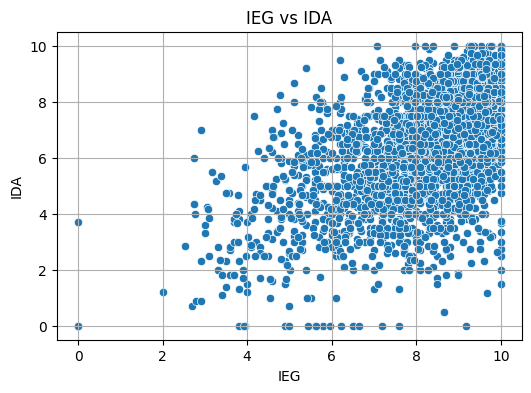

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x=col_ieg, y=col_ida)
plt.title("IEG vs IDA")
plt.grid()
plt.show()

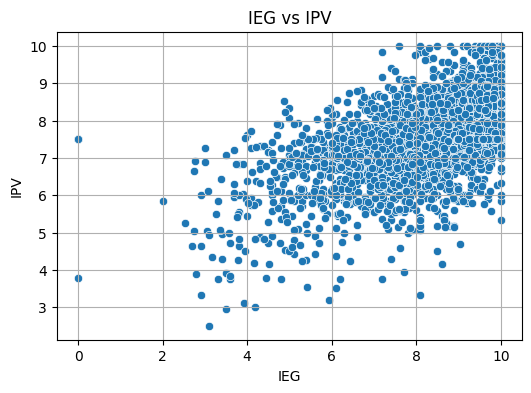

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x=col_ieg, y=col_ipv)
plt.title("IEG vs IPV")
plt.grid()
plt.show()

In [ ]:
def interpreta_corr(valor):
    if abs(valor) >= 0.7:
        return "forte"
    elif abs(valor) >= 0.4:
        return "moderada"
    elif abs(valor) >= 0.2:
        return "fraca"
    else:
        return "muito fraca ou inexistente"

print("\n Interpretação:")

print(f"IEG x IDA: relação {interpreta_corr(corr_ieg_ida)} ({corr_ieg_ida:.2f})")

print(f"IEG x IPV: relação {interpreta_corr(corr_ieg_ipv)} ({corr_ieg_ipv:.2f})")

if corr_ieg_ida > 0:
    print("Quanto maior o engajamento, maior tende a ser o desempenho (IDA).")
else:
    print("Maior engajamento não está associado a melhor desempenho.")

if corr_ieg_ipv > 0:
    print("Engajamento também está associado ao ponto de virada (IPV).")
else:
    print("Engajamento não explica bem o ponto de virada.")


 Interpretação:
IEG x IDA: relação moderada (0.54)
IEG x IPV: relação moderada (0.56)
Quanto maior o engajamento, maior tende a ser o desempenho (IDA).
Engajamento também está associado ao ponto de virada (IPV).


#4. Autoavaliação (IAA)
As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu
desempenho real (IDA) e engajamento (IEG)?

In [ ]:
df = pd.read_csv("base_historico.csv")

print(df.columns)

Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra', 'INDE',
       'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Ano', 'Data de Nasc', 'IPP', 'Escola',
       'Ativo/ Inativo'],
      dtype='object')


In [ ]:
col_iaa = "IAA"
col_ida = "IDA"
col_ieg = "IEG"


In [ ]:
df = df[[col_iaa, col_ida, col_ieg]].dropna()

In [ ]:
corr_iaa_ida = df[col_iaa].corr(df[col_ida])
corr_iaa_ieg = df[col_iaa].corr(df[col_ieg])

print("\n Correlações:")
print(f"IAA x IDA: {corr_iaa_ida:.3f}")
print(f"IAA x IEG: {corr_iaa_ieg:.3f}")


 Correlações:
IAA x IDA: 0.115
IAA x IEG: 0.131


In [ ]:
df["gap_desempenho"] = df[col_iaa] - df[col_ida]
df["gap_engajamento"] = df[col_iaa] - df[col_ieg]

print("\n Estatísticas dos gaps:")
print(df[["gap_desempenho", "gap_engajamento"]].describe())


 Estatísticas dos gaps:
       gap_desempenho  gap_engajamento
count     2851.000000      2851.000000
mean         1.552776        -0.302761
std          3.080380         2.866882
min         -9.900000       -10.000000
25%          0.400000        -1.000000
50%          1.800000         0.000000
75%          3.400000         1.105198
max          9.600000         9.168000


In [ ]:
def classificar(gap):
    if gap > 1:
        return "Superestima"
    elif gap < -1:
        return "Subestima"
    else:
        return "Realista"

df["perfil_percepcao"] = df["gap_desempenho"].apply(classificar)

print("\n Distribuição dos perfis:")
print(df["perfil_percepcao"].value_counts())


 Distribuição dos perfis:
perfil_percepcao
Superestima    1863
Realista        660
Subestima       328
Name: count, dtype: int64


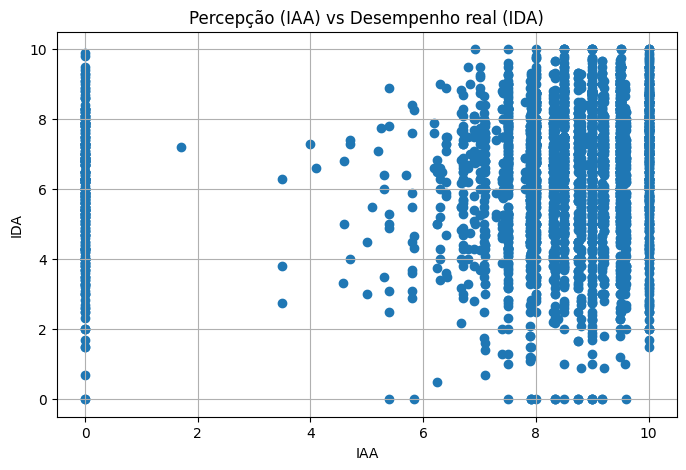

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df[col_iaa], df[col_ida])
plt.title("Percepção (IAA) vs Desempenho real (IDA)")
plt.xlabel("IAA")
plt.ylabel("IDA")
plt.grid()
plt.show()

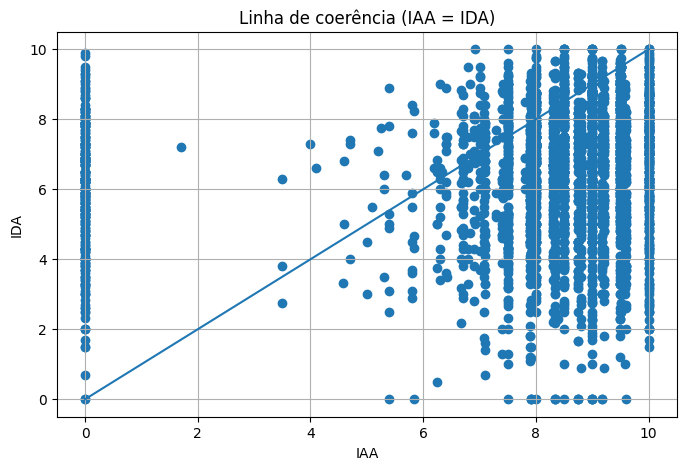

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df[col_iaa], df[col_ida])
plt.plot([df[col_iaa].min(), df[col_iaa].max()],
         [df[col_iaa].min(), df[col_iaa].max()])
plt.title("Linha de coerência (IAA = IDA)")
plt.xlabel("IAA")
plt.ylabel("IDA")
plt.grid()
plt.show()

In [ ]:
def interpretar_corr(valor):
    if abs(valor) < 0.3:
        return "fraca"
    elif abs(valor) < 0.6:
        return "moderada"
    else:
        return "forte"

print("\n Interpretação:")

print(f"A relação entre IAA e IDA é {interpretar_corr(corr_iaa_ida)}.")
print(f"A relação entre IAA e IEG é {interpretar_corr(corr_iaa_ieg)}.")


 Interpretação:
A relação entre IAA e IDA é fraca.
A relação entre IAA e IEG é fraca.
